### COCO-Stuff Distributions

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
os.chdir("..")  # go to project root
print(f"cwd: {os.getcwd()}")  # sanity check

from main import instantiate_from_config, DataModuleFromConfig
from omegaconf import OmegaConf
import numpy as np
from tqdm.notebook import tqdm
import torch
import json
import matplotlib.pyplot as plt

cwd: /home/dude-desktop/dev/taming-transformers


In [4]:
LOAD = True

In [5]:
DATA_CONFIG = """
target: main.DataModuleFromConfig
params:
    num_workers: 2
    batch_size: 32
    train:
      target: taming.data.coco.CocoImagesAndCaptionsTrain
      params:
        size: 296
        crop_size: 256
        onehot_segmentation: true
        use_stuffthing: true
    validation:
      target: taming.data.coco.CocoImagesAndCaptionsValidation
      params:
        size: 256
        crop_size: 256
        onehot_segmentation: true
        use_stuffthing: true
"""

data_cfg = OmegaConf.create(DATA_CONFIG)

In [6]:
data: DataModuleFromConfig = instantiate_from_config(data_cfg)
data.prepare_data()
data.setup()
train_ldr = data.train_dataloader()
val_ldr = data.val_dataloader()

ImgToCaptions: 100%|██████████| 25014/25014 [00:00<00:00, 1098634.72it/s]


In [7]:
print(f"Train dataset size: {len(train_ldr.dataset)}")
print(f"Validation dataset size: {len(val_ldr.dataset)}")

Train dataset size: 118287
Validation dataset size: 5000


In [8]:
with open("data/cocostuffthings/labels.txt", "r") as f:
    labels = [line.strip().split(": ")[1] for line in f.readlines()]
print(labels)

['unlabeled', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'street sign', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'hat', 'backpack', 'umbrella', 'shoe', 'eye glasses', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'plate', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'mirror', 'dining table', 'window', 'desk', 'toilet', 'door', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'blender', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush', 'hair brush', 'banner', 

#### Pixel-level class distributions
For all images, display class distribution over all pixels

In [9]:
def calculate_pixel_level_distribution(loader, num_classes):
    class_counts = torch.zeros(num_classes, dtype=torch.int64, device='cpu')
    
    for batch in tqdm(loader, desc="Calculating pixel distribution"):
        try:
            segmentations = batch["segmentation"]
            index_mask = torch.argmax(segmentations, dim=3)
            counts = torch.bincount(
                index_mask.cpu().flatten(), 
                minlength=num_classes
            )
            class_counts += counts
        except Exception as e:
            print("counts shape:", counts.shape)
            print("class_counts shape:", class_counts.shape)
            raise e

    total_pixels = class_counts.sum().item()
    return class_counts.numpy(), total_pixels

num_classes = len(labels)
if not LOAD:
    train_class_counts, train_total_pixels = calculate_pixel_level_distribution(train_ldr, num_classes)
    val_class_counts, val_total_pixels = calculate_pixel_level_distribution(val_ldr, num_classes)

In [10]:
if not LOAD:
    data = {
        "labels": labels,
        "train": {
            "class_counts": train_class_counts.tolist(),
            "total_pixels": train_total_pixels,
        },
        "validation": {
            "class_counts": val_class_counts.tolist(),
            "total_pixels": val_total_pixels,
        }
    }
    with open("analysis/pixel_level_distribution.json", "w") as f:
        json.dump(data, f, indent=4)
else:
    with open("analysis/pixel_level_distribution.json", "r") as f:
        data = json.load(f)
    labels = data["labels"]
    train_class_counts = np.array(data["train"]["class_counts"])
    train_total_pixels = data["train"]["total_pixels"]
    val_class_counts = np.array(data["validation"]["class_counts"])
    val_total_pixels = data["validation"]["total_pixels"]

#### Image-level class distributions
For all images, if an image has at least 1 pixel with the class, increment the counter for that class

In [11]:
for item in train_ldr.dataset:
    print(item.keys())
    break

dict_keys(['image', 'caption', 'segmentation', 'img_path', 'seg_path', 'filename_'])


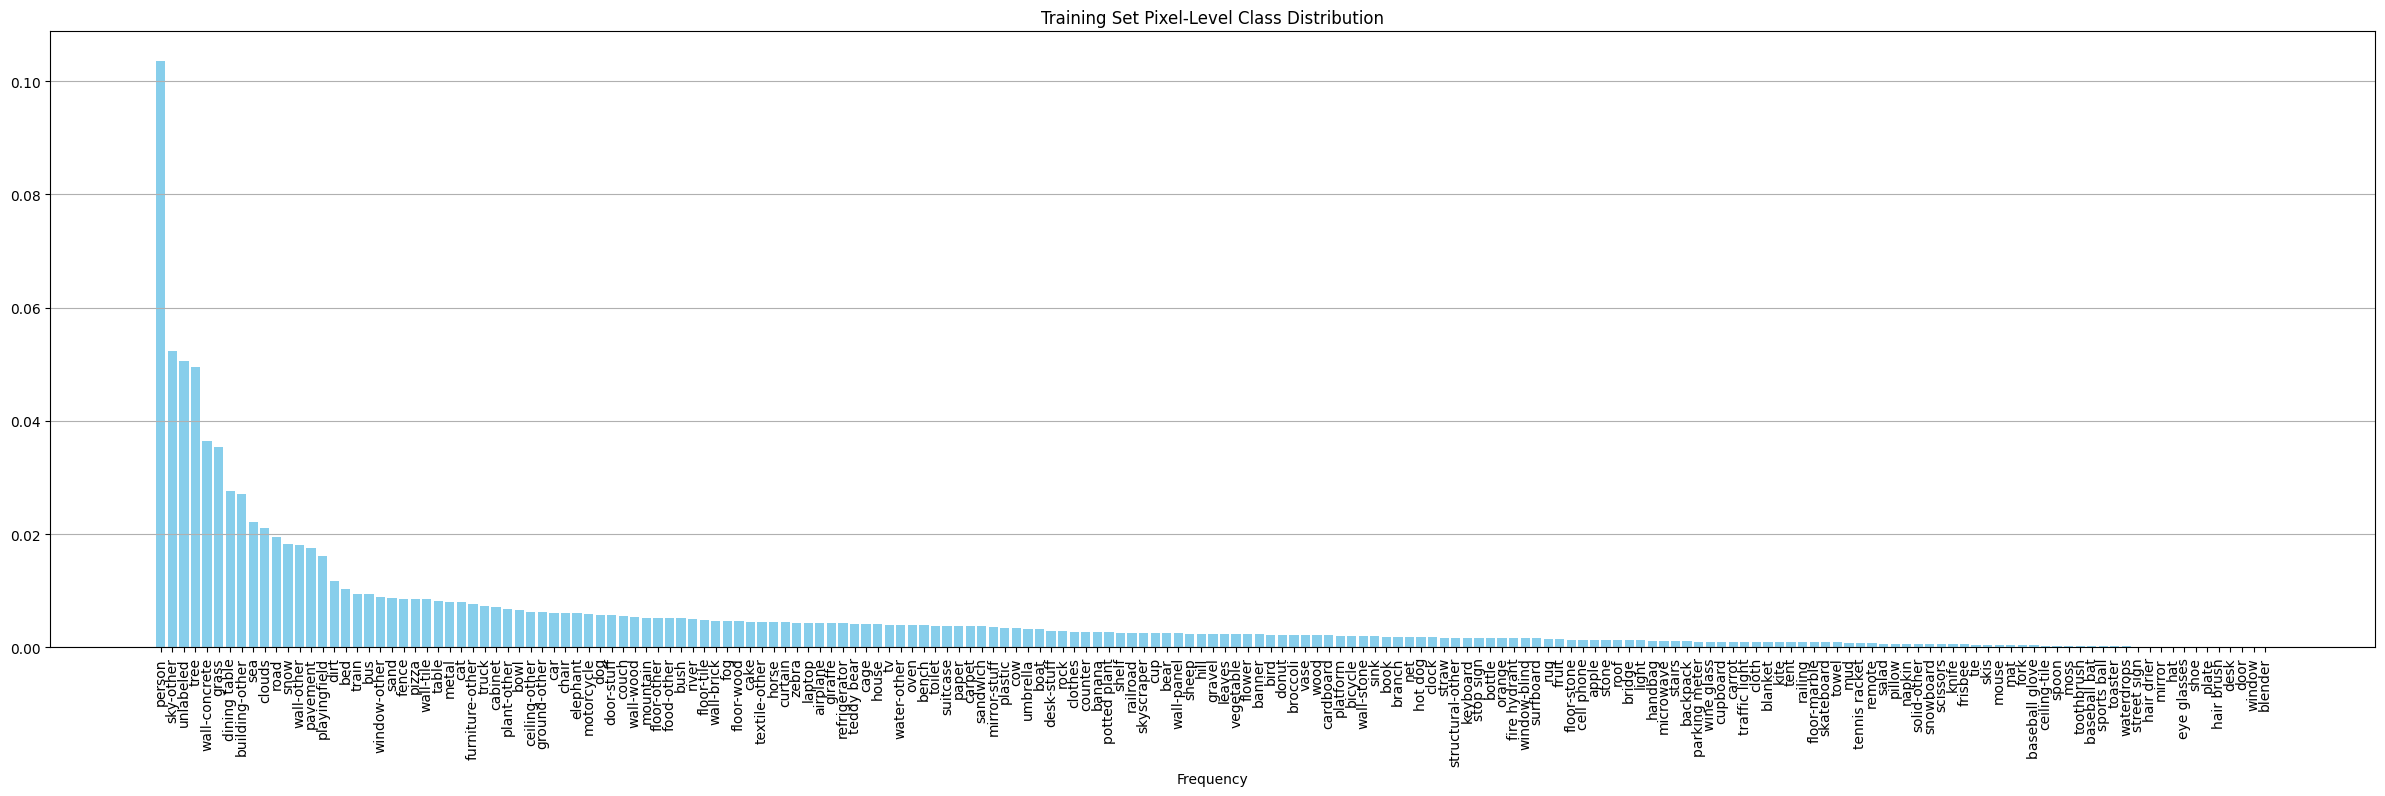

Top 5 classes by pixel frequency:
person, sky-other, unlabeled, tree, wall-concrete

Bottom 5 classes by pixel frequency:
hair brush, desk, door, window, blender


In [ ]:
def plot_distribution(class_counts, total_pixels, labels, title, save_path=None):
    class_frequencies = class_counts / total_pixels
    sorted_indices = np.argsort(class_frequencies)[::-1]
    sorted_frequencies = class_frequencies[sorted_indices]
    sorted_labels = [labels[i] for i in sorted_indices]

    plt.figure(figsize=(30, 8))
    plt.bar(sorted_labels, sorted_frequencies, color='skyblue')
    plt.xlabel('Frequency')
    plt.title(title)
    plt.grid(axis='y')
    # hide x-axis labels for better readability
    plt.xticks(rotation=90)
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    # print the top 5 classes
    print("Top 5 classes by pixel frequency:")
    print(", ".join(sorted_labels[:5]))
    print("\nBottom 5 classes by pixel frequency:")
    print(", ".join(sorted_labels[-5:]))

plot_distribution(
    train_class_counts,
    train_total_pixels,
    labels,
    "Training Set Pixel-Level Class Distribution",
    save_path="analysis/figs/train_distribution.png"
)

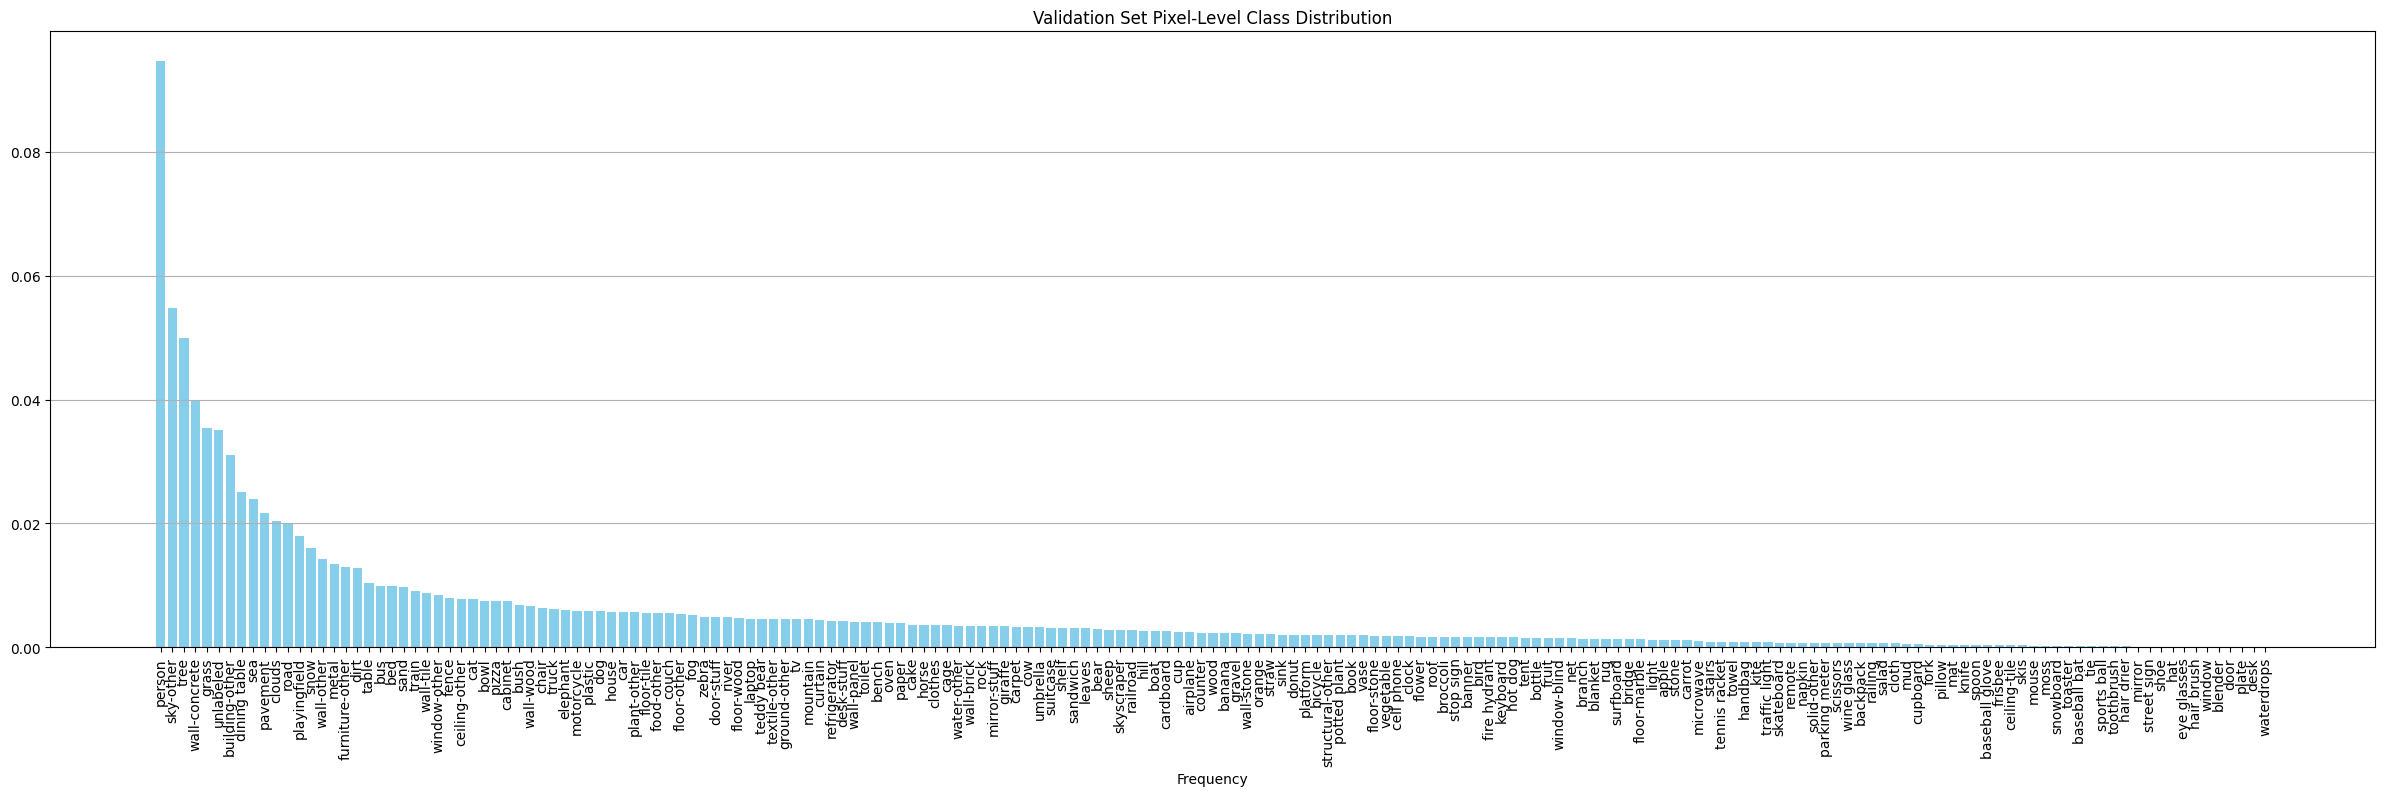

Top 5 classes by pixel frequency:
person, sky-other, tree, wall-concrete, grass

Bottom 5 classes by pixel frequency:
blender, door, plate, desk, waterdrops


In [ ]:
plot_distribution(
    val_class_counts,
    val_total_pixels,
    labels,
    "Validation Set Pixel-Level Class Distribution",
    save_path="analysis/figs/val_distribution.png"
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


TypeError: Invalid shape () for image data

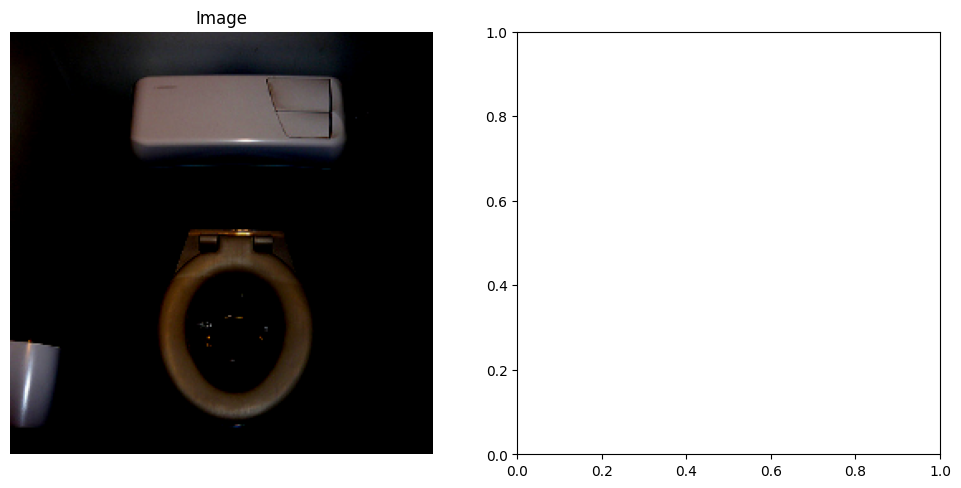

In [35]:
# plot 5 random segmentations from the validation set
import random
for _ in range(5):
    idx = random.randint(0, len(val_ldr.dataset) - 1)
    item = val_ldr.dataset[idx]
    image = item["image"]
    segmentation = item["segmentation"].argmax()

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(segmentation, cmap='jet', vmin=0, vmax=len(labels)-1)
    plt.title("Segmentation")
    plt.axis('off')

    plt.show()

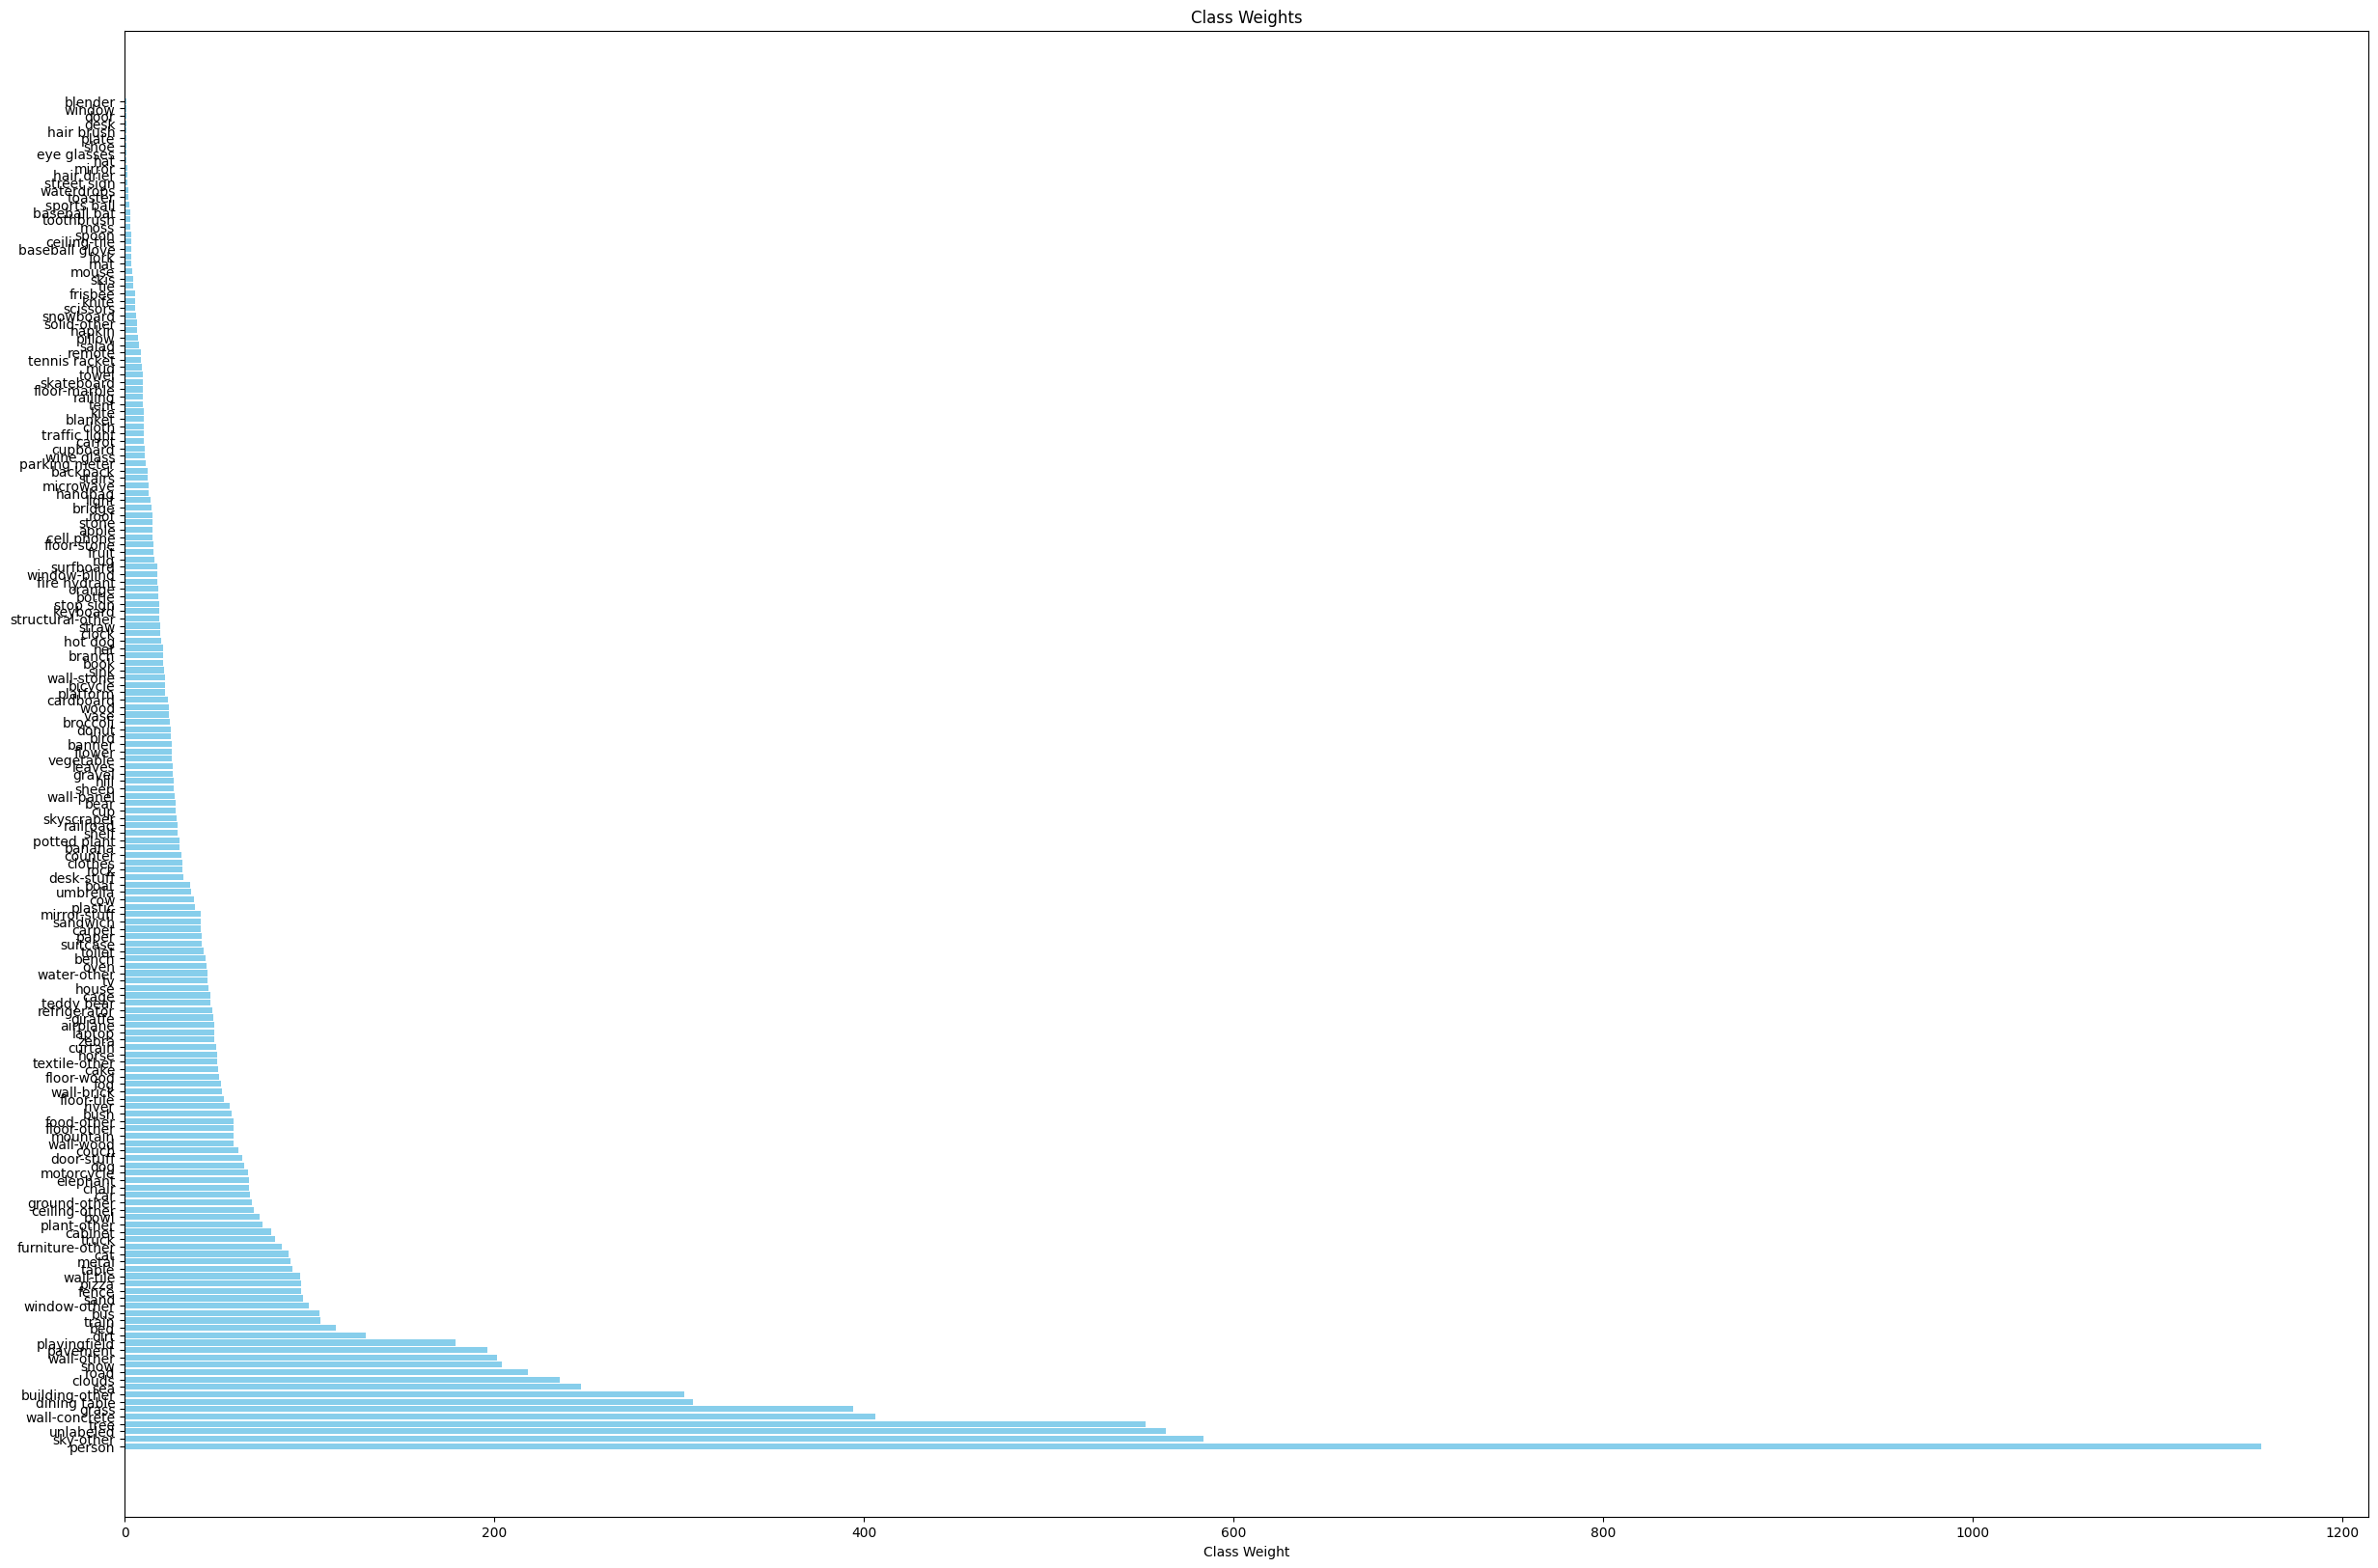

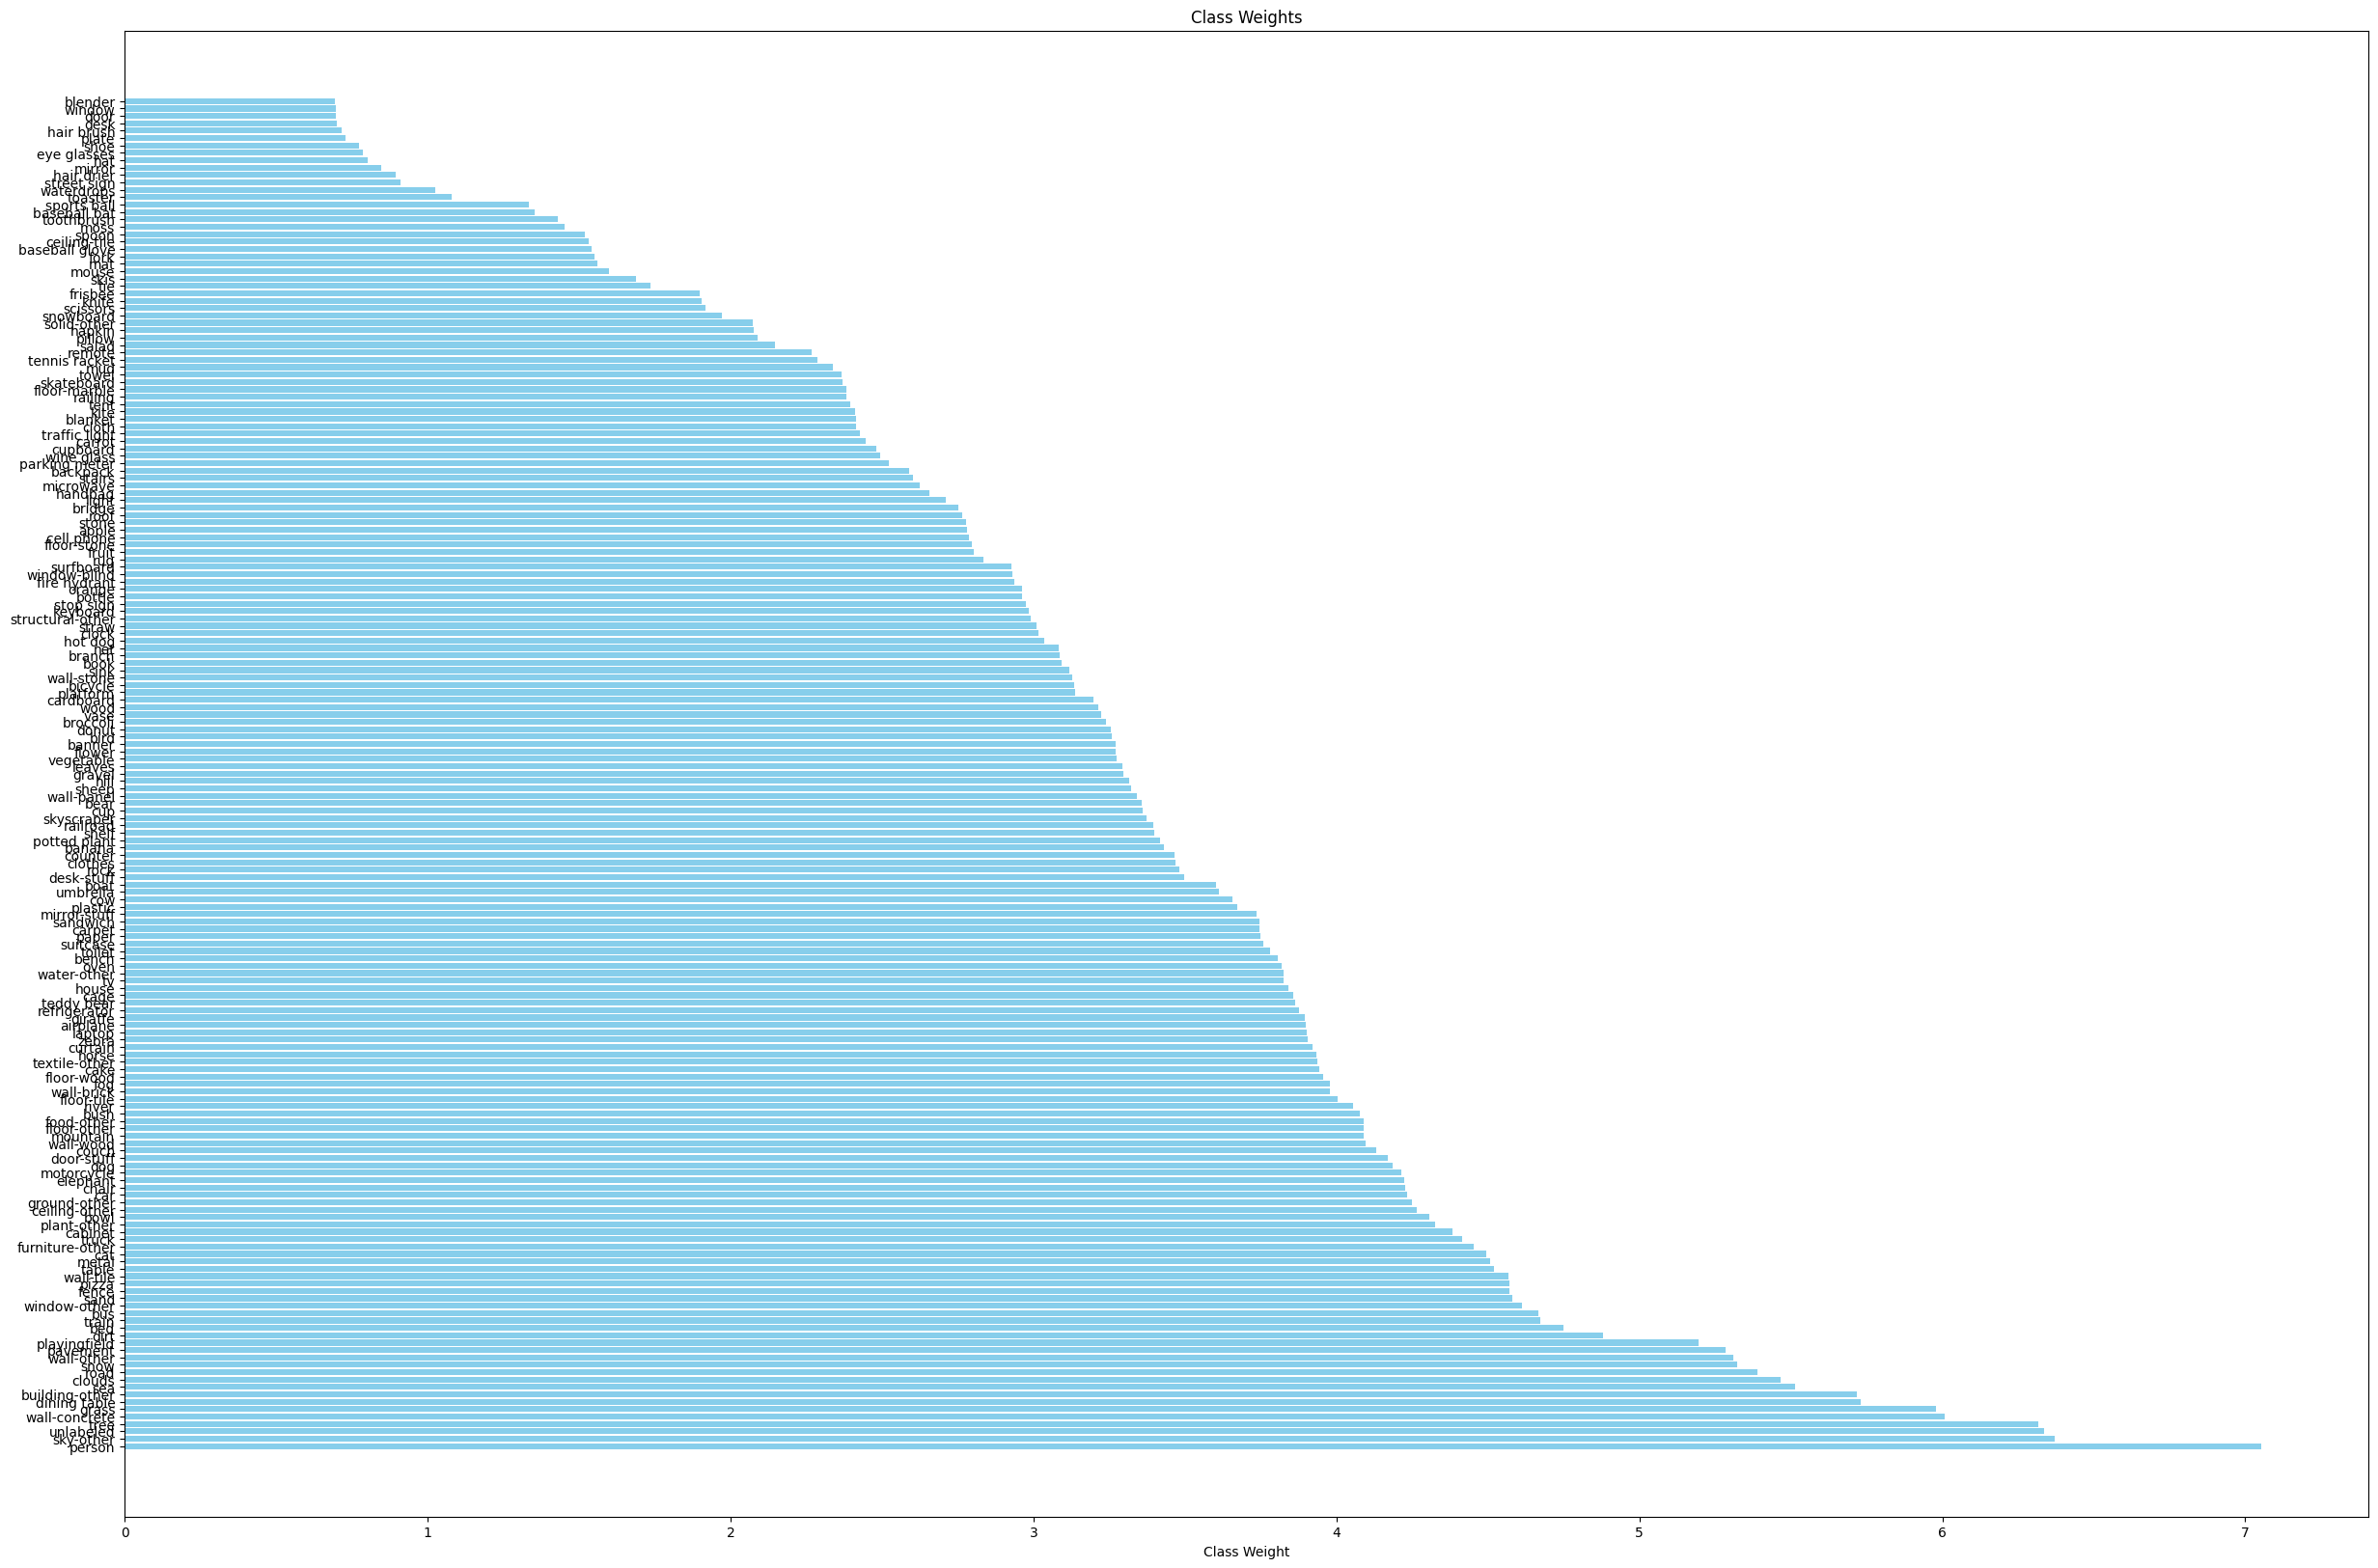

In [14]:
def write_yaml_class_weights_norm(class_counts, total_pixels, labels, filename):
    class_frequencies = class_counts / total_pixels
    # normalize so minimum weight is 1
    class_freq_norm = class_frequencies / class_frequencies.min()
    with open(filename, "w") as f:
        f.write("class_weights: {}".format(class_freq_norm.tolist()))
    return class_freq_norm

def write_yaml_log_class_weights_norm(class_counts, total_pixels, labels, filename):
    class_frequencies = class_counts / total_pixels
    # normalize so minimum weight is 1
    class_freq_norm = class_frequencies / class_frequencies.min()
    class_freq_log_norm = np.log(class_freq_norm + 1)
    with open(filename, "w") as f:
        f.write("class_weights: {}".format(class_freq_log_norm.tolist()))
    return class_freq_log_norm

def plot_class_weights(class_weights):
    sorted_indices = np.argsort(class_weights)[::-1]
    sorted_weights = class_weights[sorted_indices]
    sorted_labels = [labels[i] for i in sorted_indices]

    plt.figure(figsize=(30, 20))
    plt.barh(sorted_labels, sorted_weights, color='skyblue')
    plt.xlabel('Class Weight')
    plt.title('Class Weights')
    plt.show()

plot_class_weights(write_yaml_class_weights_norm(train_class_counts, train_total_pixels, labels, "analysis/coco_class_weights_norm.yaml"))
plot_class_weights(write_yaml_log_class_weights_norm(train_class_counts, train_total_pixels, labels, "analysis/coco_class_weights_log_norm.yaml"))